In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import csv
import lightkurve as lk

In [49]:
def histogram_multiple_dist(file, skip, teff_ranges, rad_min, rad_max):
    df_combined = pd.DataFrame()
    plt.figure(figsize=(10, 6))

    df = pd.read_csv(file, skiprows=skip)

    if 'Stellar Eff Temp (K)' in df.columns:
        df.rename(columns={'Stellar Eff Temp (K)': 'st_teff'}, inplace=True)
    if 'Planet Radius (R_Earth)' in df.columns:
        df.rename(columns={'Planet Radius (R_Earth)': 'pl_rade'}, inplace=True)

    df = df.dropna(subset=['st_teff', 'pl_rade'])
    df = df[(df['pl_rade'] < rad_max) & (df['pl_rade'] > rad_min)]

    if 'tfopwg_disp' in df.columns:
        df = df[df['tfopwg_disp'] != 'FP']

    for teff_min, teff_max in teff_ranges:
        df_filtered = df[(df['st_teff'] < teff_max) & (df['st_teff'] > teff_min)]
        df_combined = pd.concat([df_combined, df_filtered], ignore_index=True)

        plt.scatter(df_filtered['pl_rade'], df_filtered['st_dist'], alpha=0.5, label=f'{teff_min}-{teff_max}K')
        if 'pl_name' in df_filtered.columns:
            for i, txt in enumerate(df_filtered['pl_name']):
                plt.annotate(txt, (df_filtered['pl_rade'].iloc[i], df_filtered['st_dist'].iloc[i]), fontsize=8, alpha=0.7)

    try:
        df_combined = df_combined[df_combined['pl_name'].isnull() | ~df_combined[df_combined['pl_name'].notnull()].duplicated(subset='pl_name', keep='first')]
    except KeyError as e:
        print(f"KeyError: {e}")

    df_combined.rename(columns={'tid': 'tic_id', 'TIC ID': 'tic_id'}, inplace=True)

    plt.title('Planetary Radius vs Stellar Distance')
    plt.ylabel('Stellar Dist (pc)')
    plt.xlabel('Planetary Radius (Earth Radii)')
    plt.ylim(0,500)
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.figure(figsize=(10, 6))
    mean_median_data = []
    
    for teff_min, teff_max in teff_ranges:
        df_filtered = df[(df['st_teff'] < teff_max) & (df['st_teff'] > teff_min)]
        plt.hist(df_filtered['st_dist'], alpha=0.5, label=f'{teff_min}-{teff_max}K')

        # Calculate mean and median
        mean = df_filtered['st_dist'].mean()
        median = df_filtered['st_dist'].median()

        # Save mean and median to the list
        mean_median_data.append({'Teff Range': f'{teff_min}-{teff_max}K', 'Mean': mean, 'Median': median})

        # Plot median line
        color = plt.gca().patches[-1].get_facecolor()  # Get the color of the last histogram bar
        plt.axvline(median, linestyle='dashed', linewidth=2, color=color, label=f'median, {teff_min}-{teff_max}K')
        plt.text(median, plt.ylim()[1] * 0.8, f'{median:.2f}', fontsize=8, rotation=90, verticalalignment='center')

    # Save the mean and median data to a CSV file
    # with open('mean_median_data.csv', mode='w', newline='') as file:
    #     writer = csv.DictWriter(file, fieldnames=['Teff Range', 'Mean', 'Median'])
    #     writer.writeheader()
    #     writer.writerows(mean_median_data)

    plt.xlabel('Stellar Distance (pc)')
    plt.ylabel('Frequency')
    plt.title('Histogram of Planetary Radius')
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)
    plt.grid(True)
    plt.xlim(0, 500)
    #plt.ylim(0, 150)
    plt.show()

    # # Cumulative distribution lines
    # fig, ax1 = plt.subplots(figsize=(10, 6))
    # for teff_min, teff_max in teff_ranges:
    #     df_filtered = df[(df['st_teff'] < teff_max) & (df['st_teff'] > teff_min)]
    #     ax1.hist(df_filtered['pl_rade'], bins=len(df_filtered['pl_rade'])*3, alpha=0.5, label=f'{teff_min}-{teff_max}K', cumulative=True, histtype='step', density=True)

    # ax1.set_xlabel('Planetary Radius (Earth Radii)')
    # ax1.set_ylabel('Cumulative Frequency')
    # ax1.set_title('Cumulative Distribution of Planetary Radius')
    # ax1.legend()
    # ax1.grid(True)

    # plt.show()


KeyError: 'pl_name'


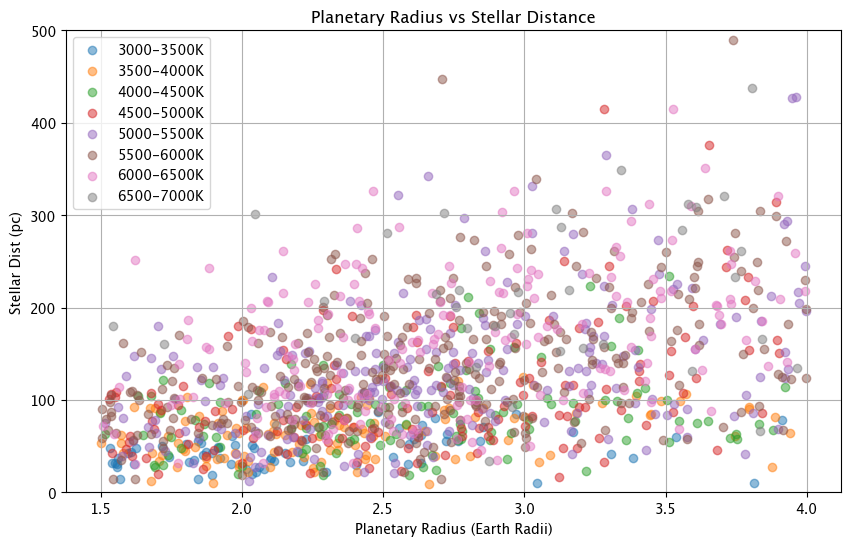

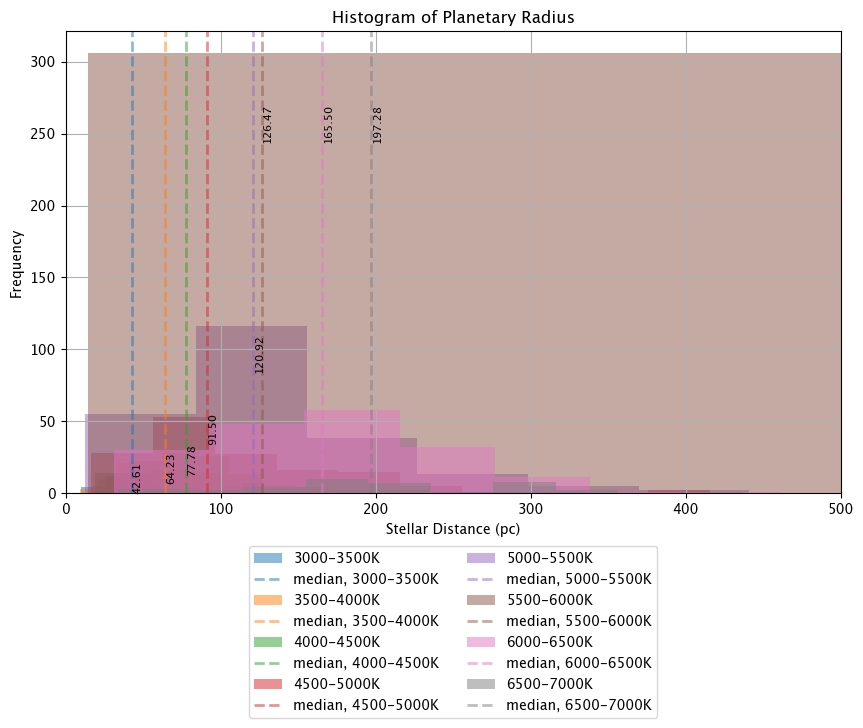

In [56]:
teff_ranges = [(3000, 3500), (3500, 4000), (4000, 4500), (4500, 5000), (5000, 5500),(5500, 6000),  (6000, 6500), (6500, 7000)]
rad_min = 1.5
rad_max = 4

#(5500, 6000),

histogram_multiple_dist('TOI_Mar2025.csv', 0, teff_ranges, rad_min, rad_max)



In [57]:
def histogram_multiple_magnitude(file, skip, teff_ranges, rad_min, rad_max):
    df_combined = pd.DataFrame()
    plt.figure(figsize=(10, 6))

    df = pd.read_csv(file, skiprows=skip)

    if 'Stellar Eff Temp (K)' in df.columns:
        df.rename(columns={'Stellar Eff Temp (K)': 'st_teff'}, inplace=True)
    if 'Planet Radius (R_Earth)' in df.columns:
        df.rename(columns={'Planet Radius (R_Earth)': 'pl_rade'}, inplace=True)

    df = df.dropna(subset=['st_teff', 'pl_rade'])
    df = df[(df['pl_rade'] < rad_max) & (df['pl_rade'] > rad_min)]

    if 'tfopwg_disp' in df.columns:
        df = df[df['tfopwg_disp'] != 'FP']

    for teff_min, teff_max in teff_ranges:
        df_filtered = df[(df['st_teff'] < teff_max) & (df['st_teff'] > teff_min)]
        df_combined = pd.concat([df_combined, df_filtered], ignore_index=True)

        plt.scatter(df_filtered['pl_rade'], df_filtered['st_tmag'],  label=f'{teff_min}-{teff_max}K')


    try:
        df_combined = df_combined[df_combined['pl_name'].isnull() | ~df_combined[df_combined['pl_name'].notnull()].duplicated(subset='pl_name', keep='first')]
    except KeyError as e:
        print(f"KeyError: {e}")

    df_combined.rename(columns={'tid': 'tic_id', 'TIC ID': 'tic_id'}, inplace=True)

    plt.title('Planetary Radius vs TESS Magnitude')
    plt.ylabel('TESS Magnitude')
    plt.xlabel('Planetary Radius (Earth Radii)')
    #plt.ylim(0,500)
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.figure(figsize=(10, 6))
    plt.show()
    plt.figure(figsize=(10, 6))

    for teff_min, teff_max in teff_ranges:
        df_combined = df[(df['st_teff'] < teff_max) & (df['st_teff'] > teff_min)]
        plt.hist(df_combined['st_tmag'], alpha=0.5, label=f'{teff_min}-{teff_max}K')

        mean = df_combined['st_tmag'].mean()
        median = df_combined['st_tmag'].median()


        # Plot median line
        color = plt.gca().patches[-1].get_facecolor()  # Get the color of the last histogram bar
        plt.axvline(median, linestyle='dashed', linewidth=2, color=color, label=f'median, {teff_min}-{teff_max}K')
        plt.text(median, plt.ylim()[1] * 0.8, f'{median:.2f}', fontsize=8, rotation=90, verticalalignment='center')
    plt.xlabel('TESS Magnitude')
    plt.ylabel('Frequency')
    plt.title('Histogram of TESS Magnitude')
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)
    plt.grid(True)
    plt.show()


KeyError: 'pl_name'


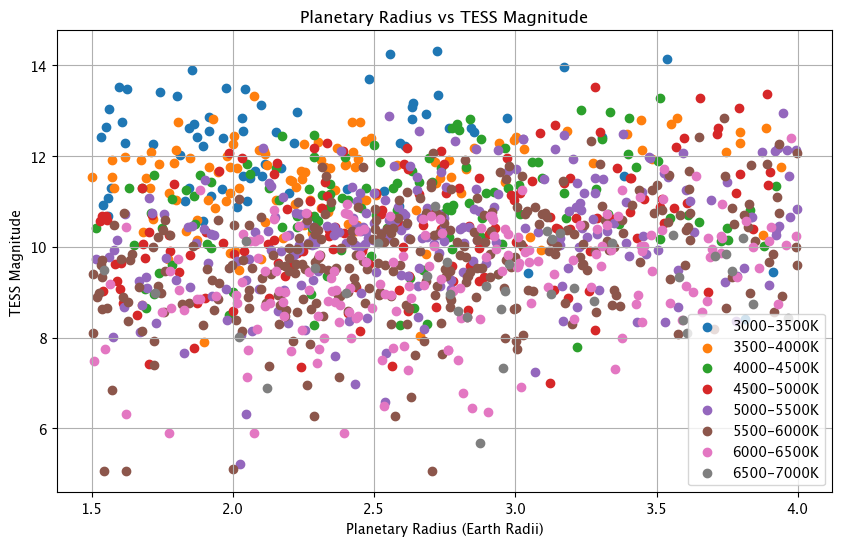

<Figure size 1000x600 with 0 Axes>

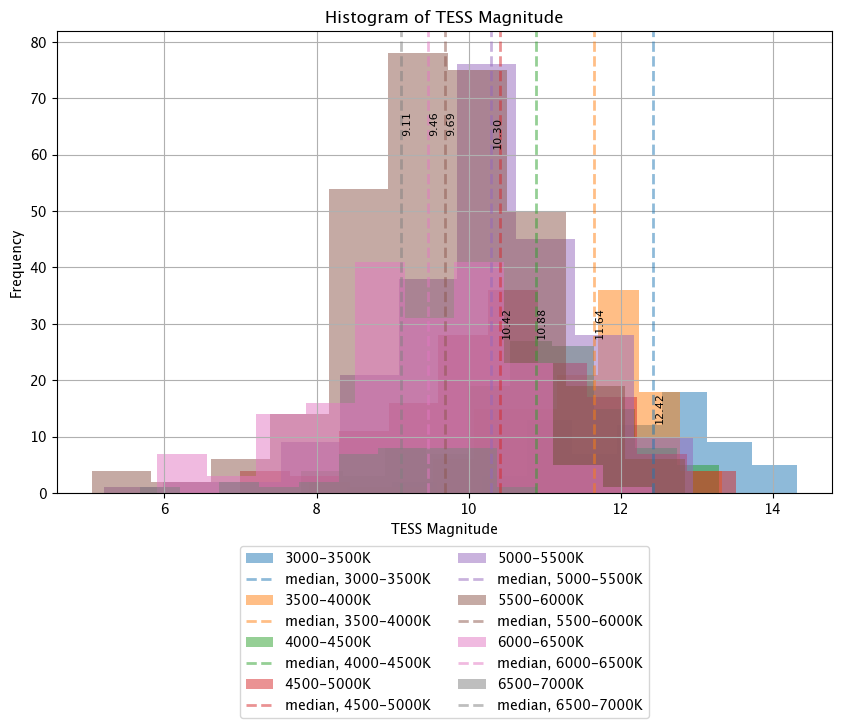

In [58]:
teff_ranges = [(3000, 3500), (3500, 4000), (4000, 4500), (4500, 5000), (5000, 5500), (5500, 6000), (6000, 6500), (6500, 7000)]
rad_min = 1.5
rad_max = 4

histogram_multiple_magnitude('TOI_Mar2025.csv', 0, teff_ranges, rad_min, rad_max)



In [1]:
from lightkurve import search_lightcurve

def histogram_multiple_uncert(file, skip, teff_ranges, rad_min, rad_max):
    df_combined = pd.DataFrame()
    plt.figure(figsize=(10, 6))

    df = pd.read_csv(file, skiprows=skip)
    df['cdpp'] = df['cdpp'].replace(r'[^\d.]+', '', regex=True).astype(float)

    if 'Stellar Eff Temp (K)' in df.columns:
        df.rename(columns={'Stellar Eff Temp (K)': 'st_teff'}, inplace=True)
    if 'Planet Radius (R_Earth)' in df.columns:
        df.rename(columns={'Planet Radius (R_Earth)': 'pl_rade'}, inplace=True)

    df = df.dropna(subset=['st_teff', 'pl_rade'])
    df = df[(df['pl_rade'] < rad_max) & (df['pl_rade'] > rad_min)]

    if 'tfopwg_disp' in df.columns:
        df = df[df['tfopwg_disp'] != 'FP']

    for teff_min, teff_max in teff_ranges:
        df_filtered = df[(df['st_teff'] < teff_max) & (df['st_teff'] > teff_min)]
        df_combined = pd.concat([df_combined, df_filtered], ignore_index=True)

        plt.scatter(df_filtered['pl_rade'], df_filtered['cdpp'], alpha=0.5, label=f'{teff_min}-{teff_max}K')
        if 'pl_name' in df_filtered.columns:
            for i, txt in enumerate(df_filtered['pl_name']):
                plt.annotate(txt, (df_filtered['pl_rade'].iloc[i], df_filtered['st_dist'].iloc[i]), fontsize=8, alpha=0.7)

    try:
        df_combined = df_combined[df_combined['pl_name'].isnull() | ~df_combined[df_combined['pl_name'].notnull()].duplicated(subset='pl_name', keep='first')]
    except KeyError as e:
        print(f"KeyError: {e}")

    df_combined.rename(columns={'tid': 'tic_id', 'TIC ID': 'tic_id'}, inplace=True)
    #print(df_combined)


    plt.title('Planetary Radius vs Stellar Distance')
    plt.ylabel('CDPP')
    plt.xlabel('Planetary Radius (Earth Radii)')
    #plt.ylim(0,500)
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.figure(figsize=(10, 6))
    mean_median_data = []
    
    for teff_min, teff_max in teff_ranges:
        df_filtered = df[(df['st_teff'] < teff_max) & (df['st_teff'] > teff_min)]
        plt.hist(df_filtered['cdpp'], alpha=0.5, label=f'{teff_min}-{teff_max}K')

        # Calculate mean and median
        mean = df_filtered['cdpp'].mean()
        median = df_filtered['cdpp'].median()

        # Save mean and median to the list
        mean_median_data.append({'Teff Range': f'{teff_min}-{teff_max}K', 'Mean': mean, 'Median': median})

        # Plot median line
        color = plt.gca().patches[-1].get_facecolor()  # Get the color of the last histogram bar
        plt.axvline(median, linestyle='dashed', linewidth=2, color=color, label=f'median, {teff_min}-{teff_max}K')
        plt.text(median, plt.ylim()[1] * 0.8, f'{median:.2f}', fontsize=8, rotation=90, verticalalignment='center')
        print(median)

    # Save the mean and median data to a CSV file
    # with open('mean_median_data.csv', mode='w', newline='') as file:
    #     writer = csv.DictWriter(file, fieldnames=['Teff Range', 'Mean', 'Median'])
    #     writer.writeheader()
    #     writer.writerows(mean_median_data)

    plt.xlabel('CDPP (ppm)')
    plt.ylabel('Frequency')
    plt.title('Histogram of Planetary Radius')
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)
    plt.grid(True)
    plt.xlim(0, 2500)
    #plt.ylim(0, 150)
    plt.show()

    # # Cumulative distribution lines
    # fig, ax1 = plt.subplots(figsize=(10, 6))
    # for teff_min, teff_max in teff_ranges:
    #     df_filtered = df[(df['st_teff'] < teff_max) & (df['st_teff'] > teff_min)]
    #     ax1.hist(df_filtered['pl_rade'], bins=len(df_filtered['pl_rade'])*3, alpha=0.5, label=f'{teff_min}-{teff_max}K', cumulative=True, histtype='step', density=True)

    # ax1.set_xlabel('Planetary Radius (Earth Radii)')
    # ax1.set_ylabel('Cumulative Frequency')
    # ax1.set_title('Cumulative Distribution of Planetary Radius')
    # ax1.legend()
    # ax1.grid(True)

    # plt.show()


/Users/danayaptangco/opt/anaconda3/envs/Unruh3/lib/python3.9/site-packages/lightkurve/config/__init__.py:119: UserWarning: The default Lightkurve cache directory, used by download(), etc., has been moved to /Users/danayaptangco/.lightkurve/cache. Please move all the files in the legacy directory /Users/danayaptangco/.lightkurve-cache to the new location and remove the legacy directory. Refer to https://docs.lightkurve.org/reference/config.html#default-cache-directory-migration for more information.
  warnings.warn(


KeyError: 'pl_name'


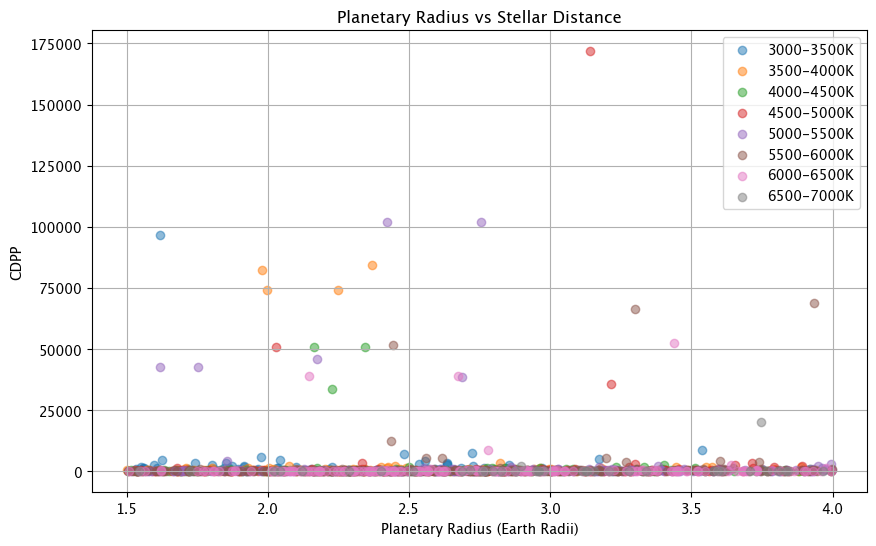

1293.6957190937665
599.3967867199419
472.38156893948553
336.10945076587586
296.95755368160053
225.90423476795883
197.79928825555635
178.4936251167114


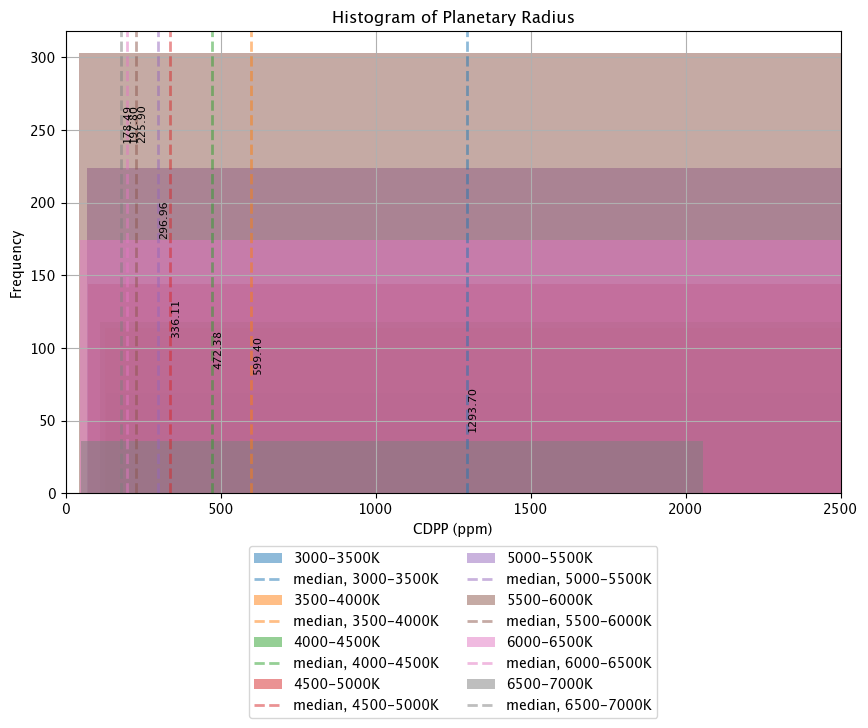

In [4]:
teff_ranges = [(3000, 3500), (3500, 4000), (4000, 4500), (4500, 5000), (5000, 5500), (5500, 6000), (6000, 6500), (6500, 7000)]
rad_min = 1.5
rad_max = 4

histogram_multiple_uncert('TOI_Mar2025.csv', 0, teff_ranges, rad_min, rad_max)

